# Figure 2 – Markovian Noise Characterization

**Device:** ibm\_algiers, qubit 8  
**Paper:** *Sparse non-Markovian Noise Modeling of Transmon-Based Multi-Qubit Operations*, PRX Quantum (2026)  

This notebook reproduces Fig. 2 in four steps:
1. Circuit generation and experiment data preview
2. Simultaneous 7-parameter Markovian noise fit
3. Exact LME simulation of all characterization experiments
4. Final publication figure

## 1  Circuit Generation and Experiment Data

In [9]:
import numpy as np
import pickle as pk
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.optimize as spopt
import qiskit as qk
import cirq

from imports_IBM_NM import (noise_characterization, cirq2qiskit, zero_cap,
                             plot_colors, Gmat, sim_exact,
                             gen_T2DD_circs, gen_fpw_circuits)

mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

ImportError: cannot import name 'plot_colors' from 'imports_IBM_NM' (C:\Users\14432\JHU\Research\Current Projects\IBM\zenodo_upload\notebooks\imports_IBM_NM.py)

In [ ]:
# ── Noise characterization object (ibm_algiers) ──
nc = noise_characterization(None, 0, m_FTTPS=6, num_T1=20, num_T2=20)

# T1
nc.num_T1     = 30
nc.T1_time    = 116   # µs
nc.T1_periods = 2
T1_circs = nc.generate_T1_circuits()

# T2 Ramsey (for x-axis) and T2 Hahn echo (for experiment data)
nc.num_T2     = 50
nc.T2_time    = 106   # µs
nc.T2_periods = 2
T2_circs   = gen_T2DD_circs(0, nc)   # Ramsey – x-axis values only
T2HE_circs = gen_T2DD_circs(1, nc)   # Hahn echo

# FTTPS (Q-filter)
nc.flip = False
nc.FTTPS_circs = nc.generate_FTTPS_circuits()

# RB
nc.rb_lens = [8, 16, 32, 64, 128, 256, 512, 1024]
nc.nseeds  = 5
nc.RB_circs = nc.generate_RB_circs()

# FPW (P-filter)
dt = nc.l_us                               # identity gate duration (µs)
nc.num_FPW  = 50
nc.step_FPW = int(50 / (nc.num_FPW * nc.l_us * 2))
nc.FPW_circs = gen_fpw_circuits(nc.num_FPW + 1, nc.step_FPW)

# ── x-axis values from circuit depths ──
circuits = {
    't1'   : T1_circs,
    't2'   : T2_circs,
    't2he' : T2HE_circs,
    'fttps': nc.FTTPS_circs,
    'fpw'  : nc.FPW_circs,
    'rb'   : nc.RB_circs,
}
x_vals = {exp: np.array([nc.l_us * (len(c) - 1) for c in cs])
          for exp, cs in circuits.items()}
x_vals['fttps']  = np.arange(nc.num_FTTPS, dtype=float)
x_vals['fpw']   *= 0.5
x_vals['rb']    /= 2.5 * dt

x_rb_mean  = np.mean(x_vals['rb'].reshape((len(nc.rb_lens), nc.nseeds)), axis=1)
nc.delays_t2 = x_vals['t2']   # referenced inside psws_char

print('Circuit counts:')
for exp, cs in circuits.items():
    print(f'  {exp:6s}: {len(cs)} circuits')

### 1.1  Load experiment data and preview (qubit 8)

In [ ]:
device = 'algiers'
qb     = 8

ps_exps_all = pk.load(open('../data/ps_exps_algiers_char.p', 'rb'))
ps_exps     = ps_exps_all[qb]

ps_rb      = np.reshape(ps_exps['rb'], (len(nc.rb_lens), nc.nseeds))
ps_rb_mean = np.mean(ps_rb, axis=1)
ps_rb_std  = np.std(ps_rb,  axis=1)

exp_preview = ['t1', 't2he', 'fttps', 'fpw', 'rb']
x_labels = {
    't1'   : r'$\tau\,(\mu s)$',
    't2he' : r'$\tau\,(\mu s)$',
    'fttps': r'$k$',
    'fpw'  : r'$\tau\,(\mu s)$',
    'rb'   : r'Clifford length $L$',
}
titles = {
    't1'   : r'(a) $T_1$',
    't2he' : r'(b) $T_2$ Hahn echo',
    'fttps': r'(c) FTTPS',
    'fpw'  : r'(d) FPW',
    'rb'   : r'(e) RB',
}

fig, axes = plt.subplots(1, 5, figsize=(22, 3.5), dpi=120)
for ax, exp in zip(axes, exp_preview):
    if exp == 'rb':
        ax.errorbar(x_rb_mean, ps_rb_mean, ps_rb_std,
                    color=plot_colors[2], ls='', marker='o', mfc='None', capsize=2)
    else:
        ax.plot(x_vals[exp], ps_exps[exp],
                color=plot_colors[2], ls='', marker='o', ms=3, mfc='None')
    ax.set_title(titles[exp], fontsize=13)
    ax.set_xlabel(x_labels[exp], fontsize=12)
    ax.set_ylabel(r'$p(|0\rangle)$', fontsize=12)
    ax.set_ylim(*(0.45, 1.05) if exp in ('t2he', 'rb') else (-0.05, 1.05))
plt.suptitle(f'ibm_{device} — qubit {qb}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2  Simultaneous 7-Parameter Markovian Noise Fit

All four characterization experiments (T1, T2 Hahn echo, FTTPS, FPW) are fitted
*simultaneously* to the Lindblad Master Equation (LME) model using `scipy.optimize.curve_fit`.

The seven free parameters are:
- `spam` – state-preparation and measurement error
- `gamma` – amplitude damping rate (1/T1)
- `q` – ground-state thermal population
- `beta` – qubit detuning (MHz)
- `lmbda` – pure dephasing rate (MHz)
- `eps` – control / amplitude error
- `nu` – gate dephasing rate (MHz)

In [ ]:
# Concatenated x-axis: T1 delays | T2 Ramsey delays | FTTPS indices | FPW delays
xx = np.concatenate([x_vals['t1'], x_vals['t2'],
                     np.arange(nc.num_FTTPS), x_vals['fpw']])

# Boolean selectors — one per piecewise segment
x_select = [
    [True]*nc.num_T1  + [False]*(nc.num_T2 + nc.num_FTTPS + nc.num_FPW),
    [False]*nc.num_T1 + [True]*nc.num_T2  + [False]*(nc.num_FTTPS + nc.num_FPW),
    [False]*(nc.num_T1 + nc.num_T2) + [True]  + [False]*(nc.num_FTTPS + nc.num_FPW - 1),
    [False]*(nc.num_T1 + nc.num_T2 + 1) + [True]*(nc.num_FTTPS - 1) + [False]*nc.num_FPW,
    [False]*(nc.num_T1 + nc.num_T2 + nc.num_FTTPS) + [True]*nc.num_FPW,
]

def psws_char(xx, spam, gamma, q, beta, lmbda, eps, nu):
    """Simultaneous LME model for T1 / T2HE / FTTPS (k=0) / FTTPS (k>0) / FPW."""
    return np.piecewise(xx, x_select, [
        # T1: amplitude damping
        lambda t: 1 - spam - q*(1 - 2*spam)*(1 - np.exp(-gamma*t)),
        # T2 Ramsey free decay (same delay times as Hahn echo)
        lambda t: 0.5*(1 + (1 - 2*spam)*np.exp(-t*(lmbda + gamma/2))),
        # FTTPS k=0
        lambda t: 0.5*(1 + (1 - 2*spam)*np.exp(-t*(lmbda + gamma/2))
                       * np.cos(beta * 2*nc.num_FTTPS*dt)),
        # FTTPS k=1 .. num_FTTPS-1
        lambda k: 0.5*(1 + (1 - 2*spam)
                       * np.exp(-(2*nc.num_FTTPS + k)*nc.l_us*gamma/4)
                       * np.exp(-2*nu*k*nc.l_us)
                       * np.exp(-(2*nc.num_FTTPS - 4 - k)*nc.l_us*lmbda/2)
                       * np.cos(np.pi*eps*k*2)),
        # FPW
        lambda t: 0.5*(1 + (1 - 2*spam)
                       * np.exp(-t*(lmbda/2 + 3*gamma/4 + nu/2))
                       * np.cos(4*beta*t/3/np.pi)),
    ])

# Initial SPAM from measurement
spam0 = float(ps_exps['spam'][0])

# Concatenated experimental data (same order as xx)
ps_combined = np.concatenate([ps_exps['t1'], ps_exps['t2he'],
                               ps_exps['fttps'], ps_exps['fpw']])

bounds = ([0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1])
params, cov = spopt.curve_fit(
    psws_char, xx, ps_combined,
    p0=(spam0, 0.01, 1., 0.5, 0.02, 0.002, 0.0),
    bounds=bounds,
)
perr = [np.sqrt(abs(cov[i, i])) for i in range(len(params))]
if float('inf') in perr:
    perr = [0]*len(params)

spam, gamma, q, beta, lmbda, eps, nu = params
lmbda = zero_cap(lmbda)

print(f'Qubit {qb} — fitted Markovian noise parameters')
print(f'  spam    : {spam*100:.3f}  +/- {perr[0]*100:.3f} %')
print(f'  gamma   : {gamma:.4f}  +/- {perr[1]:.4f} MHz   (T1 = {1/gamma:.1f} us)')
print(f'  q       : {q:.4f}  +/- {perr[2]:.4f}')
print(f'  beta    : {beta:.4f}  +/- {perr[3]:.4f} MHz')
print(f'  lmbda   : {lmbda:.4f}  +/- {perr[4]:.4f} MHz')
print(f'  epsilon : {eps:.5f} +/- {perr[5]:.5f}')
print(f'  nu      : {nu:.4f}  +/- {perr[6]:.4f} MHz')

In [ ]:
# Extract per-experiment fit curves
ps_fits_all = psws_char(xx, *params)
ps_fits = {
    't1'   : ps_fits_all[:nc.num_T1],
    't2he' : ps_fits_all[nc.num_T1 : nc.num_T1 + nc.num_T2],
    'fttps': ps_fits_all[nc.num_T1 + nc.num_T2 : nc.num_T1 + nc.num_T2 + nc.num_FTTPS],
    'fpw'  : ps_fits_all[nc.num_T1 + nc.num_T2 + nc.num_FTTPS:],
}

fit_residual = np.linalg.norm(ps_combined - ps_fits_all)
print(f'Fit residual (L2 norm): {fit_residual:.4f}')

# Diagnostic: simultaneous fit quality across all experiments
ps_labels  = ['T1', 'T2HE', 'FTTPS', 'FPW']
num_list   = [0, nc.num_T1, nc.num_T2, nc.num_FTTPS, nc.num_FPW]
color_list = [plot_colors[0], plot_colors[2], plot_colors[4], plot_colors[5]]

fig, ax = plt.subplots(figsize=(7, 2.5), dpi=150)
ax.plot(ps_combined, marker='.', ms=3, ls='-', lw=0.5, color='k', label='Experiment')
ax.plot(ps_fits_all, lw=1.5, color=plot_colors[2], label='Simultaneous fit')
for i in range(4):
    lo = int(np.sum(num_list[:i+1]))
    hi = int(np.sum(num_list[:i+2]))
    ax.axvspan(lo - 0.5, hi - 0.5, alpha=0.1, color=color_list[i])
    ax.text(lo + 1, 0.02, ps_labels[i], fontsize=9)
ax.set_ylabel('Probability', fontsize=11)
ax.set_xlabel('Experiment index', fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

## 3  Exact LME Simulation

All experiments are simulated using the Bloch-vector matrix-exponential method
(`sim_exact` from `imports_IBM_NM`) with the fitted noise parameters.

**RB correction:** SPAM is halved (`spam × 0.5`) and gate dephasing is scaled
(`nu × 1.58`) to account for the different error model in randomized benchmarking.

In [10]:
# Convert Cirq circuits to Qiskit for sim_exact
# (T1, T2HE, FTTPS, RB are Cirq;  FPW is already Qiskit)
circuits_k = {}

for k, circ in enumerate(T1_circs):
    circuits_k[f't1-{k}'] = cirq2qiskit(circ)

for k, circ in enumerate(T2HE_circs):
    circuits_k[f't2he-{k}'] = cirq2qiskit(circ)

for k, circ in enumerate(nc.FTTPS_circs):
    circ.append(cirq.measure(cirq.GridQubit(0, 0)))
    circuits_k[f'fttps-{k}'] = cirq2qiskit(circ)

for k, circ in enumerate(nc.FPW_circs):
    circuits_k[f'fpw-{k}'] = circ          # already Qiskit

for k, circ in enumerate(nc.RB_circs):
    circ.append(cirq.measure(cirq.GridQubit(0, 0)))
    circuits_k[f'rb-{k}'] = cirq2qiskit(circ)

print(f'circuits_k: {len(circuits_k)} Qiskit circuits ready')

circuits_k: 234 Qiskit circuits ready


In [11]:
# Run exact LME simulations
ps_sims = {}

sim_schedule = [
    ('t1',    nc.num_T1,           spam,       nu),
    ('t2he',  nc.num_T2,           spam,       nu),
    ('fttps', nc.num_FTTPS,        spam,       nu),
    ('fpw',   nc.num_FPW,          spam,       nu),
    ('rb',    len(nc.RB_circs),    spam*0.5,   nu*1.58),
]

for exp, n_circs, spam_s, nu_s in sim_schedule:
    print(f'Simulating {exp} ({n_circs} circuits)...', end=' ', flush=True)
    ps_sims[exp] = [
        sim_exact(circuits_k[f'{exp}-{idx}'],
                  spam_s, gamma, q, beta, lmbda, eps, nu_s)
        for idx in range(n_circs)
    ]
    print('done')

ps_sims_rb      = np.reshape(ps_sims['rb'], (len(nc.rb_lens), nc.nseeds))
ps_sims_rb_mean = np.mean(ps_sims_rb, axis=1)
ps_sims_rb_std  = np.std(ps_sims_rb,  axis=1)
print('\nSimulation complete.')

Simulating t1 (30 circuits)... done
Simulating t2he (50 circuits)... done
Simulating fttps (64 circuits)... done
Simulating fpw (50 circuits)... done
Simulating rb (40 circuits)... done

Simulation complete.


## 4  Paper Figure (Fig. 2)

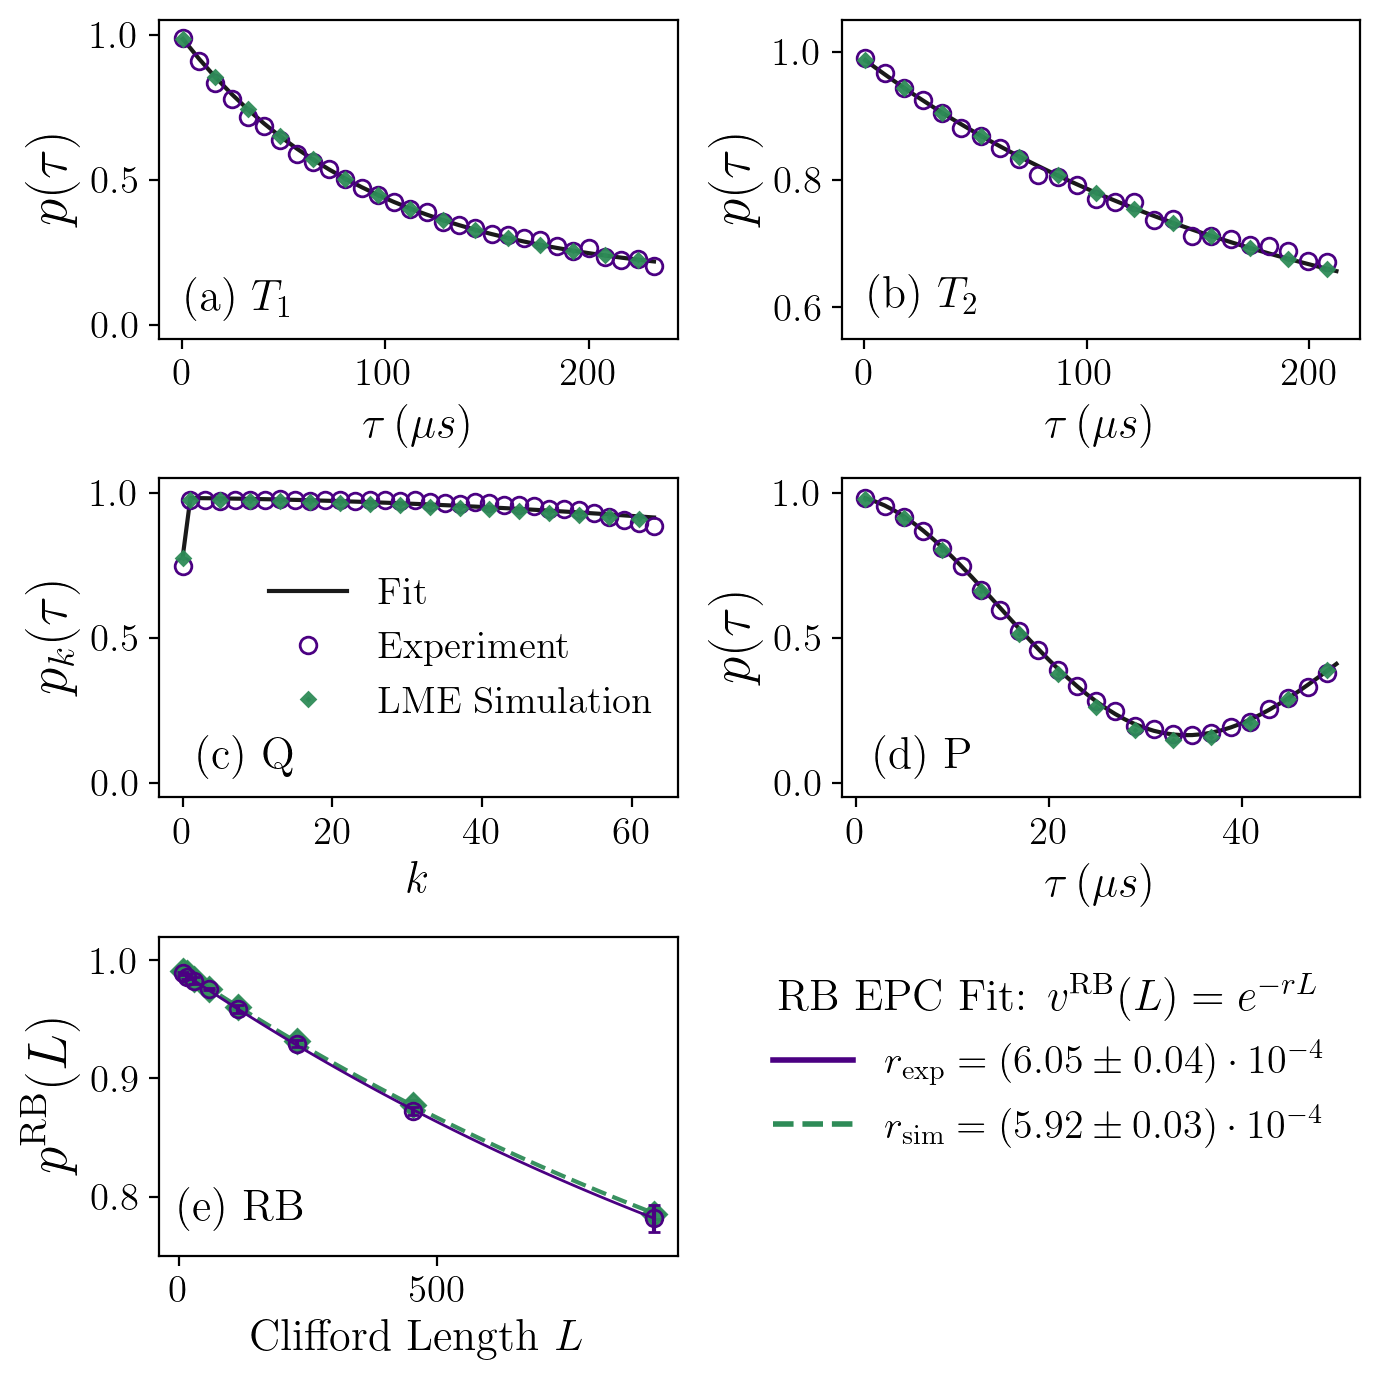

In [12]:
rb_fun = lambda t, s, r: (1 + (1 - 2*s) * np.exp(-t*r)) / 2

# ── Style ──
color_exp  = 'indigo'
color_fit  = '0.1'
color_sim  = 'seagreen'
lw_exp = 1.5;  lw_fit = 1.5;  lw_sim = 1.5
ls_exp = '';   ls_fit = '-';  ls_sim = ''
marker_exp = 'o';  marker_sim = 'D'
mew = 3;  ms = 1.5
alpha_sim = 0.95

fig = plt.figure(dpi=200, figsize=(7, 7))
gs  = fig.add_gridspec(3, 2)

# (a) T1
ax = fig.add_subplot(gs[0, 0])
ax.plot(x_vals['t1'], ps_fits['t1'],
        lw=lw_fit, ls=ls_fit, color=color_fit, alpha=1)
ax.plot(x_vals['t1'], ps_exps['t1'],
        lw=lw_exp, ls=ls_exp, marker=marker_exp, mfc='None', alpha=1, color=color_exp)
ax.plot(x_vals['t1'][::2], ps_sims['t1'][::2],
        lw=lw_sim, ls=ls_sim, marker=marker_sim, mew=mew, ms=ms,
        color=color_sim, alpha=alpha_sim)
ax.set_xlabel(r'$\tau\,(\mu s)$', fontsize=16)
ax.set_ylabel(r'$p(\tau)$', fontsize=20)
ax.set_ylim(-0.05, 1.05)
ax.text(2, 0.05, r'(a) $T_1$', size=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# (b) T2 Hahn echo
ax = fig.add_subplot(gs[0, 1])
ax.plot(x_vals['t2he'], ps_fits['t2he'],
        lw=lw_fit, ls=ls_fit, color=color_fit)
ax.plot(x_vals['t2he'][::2], ps_exps['t2he'][::2],
        lw=lw_exp, ls=ls_exp, marker=marker_exp, mfc='None', alpha=1, color=color_exp)
ax.plot(x_vals['t2he'][::4], ps_sims['t2he'][::4],
        lw=lw_sim, ls=ls_sim, marker=marker_sim, mew=mew, ms=ms,
        color=color_sim, alpha=alpha_sim)
ax.set_xlabel(r'$\tau\,(\mu s)$', fontsize=16)
ax.set_ylabel(r'$p(\tau)$', fontsize=20)
ax.set_ylim(0.55, 1.05)
ax.text(2, 0.6, r'(b) $T_2$', size=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# (c) FTTPS
ax = fig.add_subplot(gs[1, 0])
ax.plot(x_vals['fttps'], ps_fits['fttps'],
        lw=lw_fit, ls=ls_fit, color=color_fit)
ax.plot(np.concatenate(([x_vals['fttps'][0]], x_vals['fttps'][1::2])),
        np.concatenate(([ps_exps['fttps'][0]], ps_exps['fttps'][1::2])),
        lw=lw_exp, ls=ls_exp, marker=marker_exp, mfc='None', alpha=1, color=color_exp)
ax.plot(np.concatenate(([x_vals['fttps'][0]], x_vals['fttps'][1::4])),
        np.concatenate(([ps_sims['fttps'][0]], ps_sims['fttps'][1::4])),
        lw=lw_sim, ls=ls_sim, marker=marker_sim, mew=mew, ms=ms,
        color=color_sim, alpha=alpha_sim)
ax.set_xlabel(r'$k$', fontsize=16)
ax.set_ylabel(r'$p_k(\tau)$', fontsize=20)
ax.set_ylim(-0.05, 1.05)
ax.text(2, 0.05, r'(c) Q', size=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(['Fit', 'Experiment', 'LME Simulation'],
          frameon=False, fontsize=14, bbox_to_anchor=(1.02, 0.8))

# (d) FPW
ax = fig.add_subplot(gs[1, 1])
ax.plot(x_vals['fpw'], ps_fits['fpw'],
        lw=lw_fit, ls=ls_fit, color=color_fit)
ax.plot(x_vals['fpw'][::2], ps_exps['fpw'][::2],
        lw=lw_exp, ls=ls_exp, marker=marker_exp, mfc='None', alpha=1, color=color_exp)
ax.plot(x_vals['fpw'][::4], ps_sims['fpw'][::4],
        lw=lw_sim, ls=ls_sim, marker=marker_sim, mew=mew, ms=ms,
        color=color_sim, alpha=alpha_sim)
ax.set_xlabel(r'$\tau\,(\mu s)$', fontsize=16)
ax.set_ylabel(r'$p(\tau)$', fontsize=20)
ax.set_ylim(-0.05, 1.05)
ax.text(2, 0.05, r'(d) P', size=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# (e) RB
ax = fig.add_subplot(gs[2, 0])
x_rb_mean_fine = np.linspace(x_rb_mean[0], x_rb_mean[-1], 100)

ax.errorbar(x_rb_mean, ps_rb_mean, ps_rb_std,
            color=color_exp, ls=ls_exp, lw=lw_exp,
            marker=marker_exp, mfc='None', capsize=2)
params_rb, cov_rb = spopt.curve_fit(rb_fun, x_rb_mean, ps_rb_mean, p0=(0, 0))
r_exp  = params_rb[-1];  dr_exp = np.sqrt(cov_rb[1, 1])
ax.plot(x_rb_mean_fine, rb_fun(x_rb_mean_fine, *params_rb),
        color=color_exp, ls='-', lw=1)

ax.errorbar(x_rb_mean, ps_sims_rb_mean, ps_sims_rb_std,
            color=color_sim, ls=ls_sim, lw=lw_sim,
            marker=marker_sim, capsize=2, alpha=alpha_sim, zorder=-1)
params_sim, cov_sim = spopt.curve_fit(rb_fun, x_rb_mean, ps_sims_rb_mean, p0=(0, 0))
r_sim  = params_sim[-1];  dr_sim = np.sqrt(cov_sim[1, 1])
ax.plot(x_rb_mean_fine, rb_fun(x_rb_mean_fine, *params_sim),
        color=color_sim, ls='--', lw=1.5, alpha=alpha_sim, zorder=-1)

ax.text(0.5, 0.78, r'(e) RB', size=16)
ax.set_ylabel(r'$p^{\mathrm{RB}}(L)$', fontsize=20)
ax.set_xlabel(r'Clifford Length $L$', fontsize=16)
ax.set_ylim(0.75, 1.02)
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend panel
ax = fig.add_subplot(gs[2, 1])
ax.plot(0, 0, color=color_exp, ls='-',  lw=2)
ax.plot(0, 0, color=color_sim, ls='--', lw=2)
ax.axis('off')
ax.legend(
    [r'$r_{\mathrm{exp}}  = (%.2f \pm %.2f)\cdot 10^{-4}$' % (r_exp*1e4, dr_exp*1e4),
     r'$r_{\mathrm{sim}}  = (%.2f \pm %.2f)\cdot 10^{-4}$' % (r_sim*1e4, dr_sim*1e4)],
    frameon=False,
    title=r'RB EPC Fit: $v^{\mathrm{RB}}(L) = e^{-rL}$',
    fontsize=14.5, title_fontsize=16,
)

plt.tight_layout()
plt.savefig('../figures/fig_02_markovian_experiments.pdf', bbox_inches='tight')
plt.show()